# Spectrogram CNN Language Classifier

This notebook builds a language classification pipeline from `signal_data`:

1. load the train and test pickles
2. convert each waveform into a fixed-size spectrogram
3. train a CNN classifier in PyTorch
4. evaluate on the held-out test split


In [10]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.signal import stft
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(torch.__version__)


Matplotlib is building the font cache; this may take a moment.


2.12.1


In [11]:
train_df = pd.read_pickle("train_set.pkl").copy()
test_df = pd.read_pickle("test_set.pkl").copy()

# Create a stable label mapping from the training set.
label_names = sorted(train_df["language"].unique())
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

train_df["target"] = train_df["language"].map(label2id)
test_df["target"] = test_df["language"].map(label2id)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Languages:", label_names)
print(train_df[["language", "target"]].head())


Train shape: (175, 8)
Test shape: (44, 8)
Languages: ['FR', 'IT', 'PO', 'SA', 'SI']
    language  target
176       SA       3
165       FR       0
126       FR       0
103       SI       4
70        IT       1


In [12]:
# Split off a validation set from the provided train split.
train_part, val_part = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["target"],
)

# A shorter target length reduces padding and keeps the spectrograms more informative.
sample_rate = 8000
n_fft = 256
hop_length = 128
target_len = int(train_df["signal_data"].map(len).quantile(0.95))
target_len = max(target_len, n_fft)

print("Train/val split:", train_part.shape, val_part.shape)
print("Target waveform length:", target_len)


def pad_or_crop(signal, target_len=target_len, random_crop=False):
    y = np.asarray(signal, dtype=np.float32)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    elif len(y) > target_len:
        if random_crop:
            start = np.random.randint(0, len(y) - target_len + 1)
        else:
            start = (len(y) - target_len) // 2
        y = y[start : start + target_len]
    return y


def waveform_to_spectrogram(signal, augment=False):
    """Convert a waveform into a normalized log-magnitude spectrogram."""
    y = pad_or_crop(signal, random_crop=augment)

    if augment:
        shift = np.random.randint(-len(y) // 20, len(y) // 20 + 1)
        y = np.roll(y, shift)
        y = y * np.random.uniform(0.85, 1.15)
        noise_std = max(float(np.std(y)) * 0.01, 1e-6)
        y = y + np.random.normal(0.0, noise_std, size=y.shape).astype(np.float32)

    _, _, zxx = stft(
        y,
        fs=sample_rate,
        window="hann",
        nperseg=n_fft,
        noverlap=n_fft - hop_length,
        boundary=None,
        padded=False,
    )
    spec = np.log1p(np.abs(zxx))
    spec = (spec - spec.mean()) / (spec.std() + 1e-6)
    return spec.astype(np.float32)


example_spec = waveform_to_spectrogram(train_df["signal_data"].iloc[0])
print("Example spectrogram shape:", example_spec.shape)


Train/val split: (140, 8) (35, 8)
Target waveform length: 15156
Example spectrogram shape: (129, 117)


In [13]:
class SpectrogramDataset(Dataset):
    def __init__(self, frame, label_col="target", augment=False):
        self.frame = frame.reset_index(drop=True)
        self.label_col = label_col
        self.augment = augment

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        x = waveform_to_spectrogram(row["signal_data"], augment=self.augment)
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(int(row[self.label_col]), dtype=torch.long)
        return x, y


class_counts = train_part["target"].value_counts().sort_index()
sample_weights = train_part["target"].map(lambda t: 1.0 / class_counts.loc[t]).to_numpy(dtype=np.float32)
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(SpectrogramDataset(train_part, augment=True), batch_size=16, sampler=train_sampler)
val_loader = DataLoader(SpectrogramDataset(val_part), batch_size=16, shuffle=False)
test_loader = DataLoader(SpectrogramDataset(test_df), batch_size=16, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch shape:", xb.shape, yb.shape)


Batch shape: torch.Size([16, 1, 129, 117]) torch.Size([16])


In [14]:
class SpectrogramCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


device = torch.device("cuda" if torch.cuda.is_available() else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu")
model = SpectrogramCNN(num_classes=len(label_names)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
print(model)


SpectrogramCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=5, bias=

In [15]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            logits = model(x)
            loss = criterion(logits, y)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
            all_targets.extend(y.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    return avg_loss, acc


best_state = None
best_val_acc = -1.0
best_epoch = 0
patience = 8
patience_left = patience
history = []

for epoch in range(1, 31):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, val_loader)
    history.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc})
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} train_acc={train_acc:.3f} | val_loss={val_loss:.4f} val_acc={val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_left = patience
    else:
        patience_left -= 1
        if patience_left == 0:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_state)
print("Best validation accuracy:", best_val_acc)
print("Best validation epoch:", best_epoch)

# Retrain on the full labeled training data using the chosen epoch budget.
full_class_counts = train_df["target"].value_counts().sort_index()
full_sample_weights = train_df["target"].map(lambda t: 1.0 / full_class_counts.loc[t]).to_numpy(dtype=np.float32)
full_train_sampler = WeightedRandomSampler(full_sample_weights, num_samples=len(full_sample_weights), replacement=True)
full_train_loader = DataLoader(SpectrogramDataset(train_df, augment=True), batch_size=16, sampler=full_train_sampler)

final_model = SpectrogramCNN(num_classes=len(label_names)).to(device)
final_optimizer = torch.optim.AdamW(final_model.parameters(), lr=1e-3, weight_decay=1e-4)
final_epochs = max(best_epoch, 1)
for epoch in range(1, final_epochs + 1):
    train_loss, train_acc = run_epoch(final_model, full_train_loader, optimizer=final_optimizer)
    print(f"Final train {epoch:02d} | loss={train_loss:.4f} acc={train_acc:.3f}")

torch.save(final_model.state_dict(), "spectrogram_cnn.pt")
print("Final model trained on all labeled data.")


Epoch 01 | train_loss=1.5656 train_acc=0.314 | val_loss=1.5850 val_acc=0.229
Epoch 02 | train_loss=1.5377 train_acc=0.371 | val_loss=1.5576 val_acc=0.286
Epoch 03 | train_loss=1.4776 train_acc=0.414 | val_loss=1.5470 val_acc=0.314
Epoch 04 | train_loss=1.4351 train_acc=0.450 | val_loss=1.4975 val_acc=0.343
Epoch 05 | train_loss=1.4504 train_acc=0.400 | val_loss=1.4544 val_acc=0.429
Epoch 06 | train_loss=1.4074 train_acc=0.471 | val_loss=1.4005 val_acc=0.514
Epoch 07 | train_loss=1.4591 train_acc=0.414 | val_loss=1.4716 val_acc=0.371
Epoch 08 | train_loss=1.3745 train_acc=0.479 | val_loss=1.3812 val_acc=0.343
Epoch 09 | train_loss=1.3569 train_acc=0.443 | val_loss=1.3815 val_acc=0.457
Epoch 10 | train_loss=1.3459 train_acc=0.464 | val_loss=1.3615 val_acc=0.457
Epoch 11 | train_loss=1.3368 train_acc=0.443 | val_loss=1.3754 val_acc=0.514
Epoch 12 | train_loss=1.3877 train_acc=0.371 | val_loss=1.4550 val_acc=0.543
Epoch 13 | train_loss=1.3460 train_acc=0.443 | val_loss=1.4347 val_acc=0.514

Test loss=1.4892 test acc=0.477
              precision    recall  f1-score   support

          FR      0.385     0.417     0.400        12
          IT      0.500     0.900     0.643        10
          PO      0.333     0.400     0.364         5
          SA      0.714     0.556     0.625         9
          SI      0.000     0.000     0.000         8

    accuracy                          0.477        44
   macro avg      0.386     0.454     0.406        44
weighted avg      0.403     0.477     0.424        44



/opt/miniconda3/envs/kcl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/kcl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/kcl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

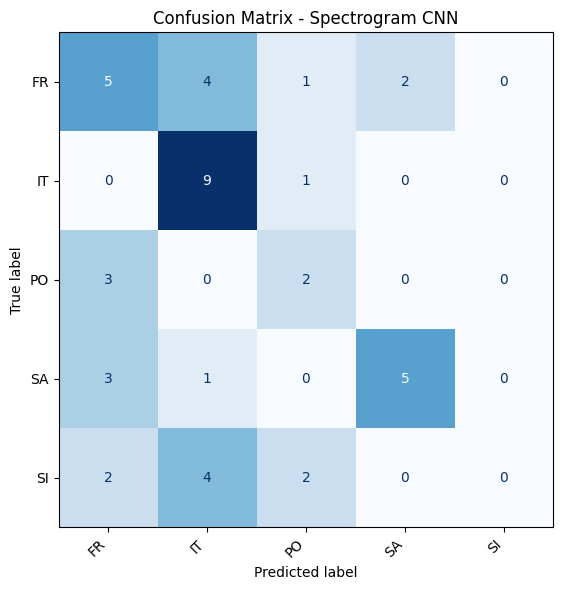

    language speaker  length  pred_id pred_language
104       SI       C    7500        2            PO
218       SA       E   11251        3            SA
64        IT       D   24456        1            IT
6         PO       A   10393        0            FR
127       FR       B    7001        0            FR


In [16]:
test_loss, test_acc = run_epoch(final_model, test_loader)
print(f"Test loss={test_loss:.4f} test acc={test_acc:.3f}")

all_preds = []
all_targets = []
final_model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = final_model(x)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_targets.extend(y.numpy())

print(classification_report(
    all_targets,
    all_preds,
    target_names=[id2label[i] for i in range(len(label_names))],
    digits=3,
))

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[id2label[i] for i in range(len(label_names))])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix - Spectrogram CNN")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix_spectrogram_cnn.png", dpi=200, bbox_inches="tight")
plt.show()

test_results = test_df[["language", "speaker", "length"]].copy()
test_results["pred_id"] = all_preds
test_results["pred_language"] = test_results["pred_id"].map(id2label)
print(test_results.head())
